# Semana 1: Fundamentos Matemáticos para IA
## Notebook 1: Notación, Funciones, Objetos y Aplicaciones

### Propósito de la sesión
Este cuaderno sienta las bases matemáticas necesarias para la inteligencia artificial. Comenzaremos con la notación compacta de sumatorias y productorias, visualizaremos las funciones más utilizadas en modelos de IA (activación y pérdida), definiremos los objetos matemáticos (escalares, vectores, matrices, tensores) y finalmente exploraremos aplicaciones como la similitud entre vectores y distancias.

### Objetivos de aprendizaje
*   Comprender y usar la notación de sumatoria (∑) y productoria (∏) con ejemplos numéricos.
*   Visualizar e interpretar funciones de activación (sigmoide, tanh, ReLU, Leaky ReLU, Swish) y funciones de pérdida (MSE, MAE, Cross-entropy, Hinge, Focal, Contrastive).
*   Representar escalares, vectores, matrices y tensores en Python con NumPy y realizar operaciones básicas.
*   Calcular similitud de coseno, distancias (euclidiana, Manhattan) y entender el kernel RBF.
*   Relacionar estos conceptos con aplicaciones reales en IA.

## Configuración Inicial

Importamos las librerías necesarias: NumPy para operaciones numéricas, Matplotlib y Seaborn para gráficos.

In [1]:
# Importamos librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para gráficos (usaremos seaborn)
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## Parte 1: Notación: Sumatorias y Productorias

La notación de sumatoria ($\sum$) y productoria ($\prod$) permite expresar de forma compacta sumas y productos de muchos términos. Son fundamentales en modelos de IA, por ejemplo, en la suma ponderada de una neurona o en el cálculo de probabilidades conjuntas.



#### Sumatoria

$$\sum_{i=1}^{n} x_i = x_1 + x_2 + \dots + x_n$$

**Ejemplo en Python:**

In [2]:
# Ejemplo de sumatoria con un bucle
numeros = [2, 4, 6, 8]
suma_bucle = 0
for num in numeros:
    suma_bucle += num
print(f"Suma con bucle: {suma_bucle}")

# Usando la función sum de Python
suma_python = sum(numeros)
print(f"Suma con sum(): {suma_python}")

# Usando numpy
suma_numpy = np.sum(numeros)
print(f"Suma con np.sum(): {suma_numpy}")

Suma con bucle: 20
Suma con sum(): 20
Suma con np.sum(): 20


#### Productoria

$$\prod_{i=1}^{n} x_i = x_1 \cdot x_2 \cdot \dots \cdot x_n$$

**Ejemplo en Python:**

In [3]:
# Ejemplo de productoria con un bucle
numeros = [2, 3, 4]
producto_bucle = 1
for num in numeros:
    producto_bucle *= num
print(f"Producto con bucle: {producto_bucle}")

# Usando numpy
producto_numpy = np.prod(numeros)
print(f"Producto con np.prod(): {producto_numpy}")

Producto con bucle: 24
Producto con np.prod(): 24


#### Aplicacion

La media se define como $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$.
La varianza muestral: $s^2 = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2$.

Veamos un ejemplo numérico:

In [4]:
datos = np.array([5, 7, 9, 11])
n = len(datos)
media = np.sum(datos) / n
varianza = np.sum((datos - media)**2) / (n-1)
print(f"Datos: {datos}")
print(f"Media: {media:.2f}")
print(f"Varianza muestral: {varianza:.2f}")

Datos: [ 5  7  9 11]
Media: 8.00
Varianza muestral: 6.67


---
## Parte 2: Funciones en IA

### 2.1. Funciones de Activación
Las funciones de activación introducen no-linealidad en las redes neuronales, permitiendo aprender patrones complejos.

#### Sigmoide
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
Se usa en la capa de salida para clasificación binaria (probabilidad).

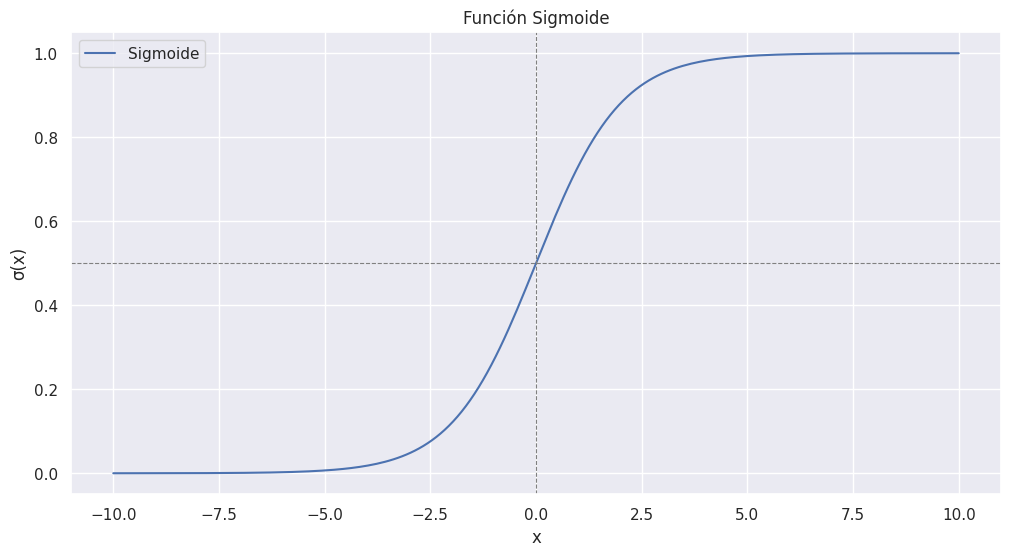

In [5]:
def sigmoide(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 200)
y_sig = sigmoide(x)

plt.figure()
sns.lineplot(x=x, y=y_sig, label='Sigmoide')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Función Sigmoide')
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.legend()
plt.show()

#### Tangente Hiperbólica (tanh)
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
Similar a la sigmoide pero centrada en cero (rango [-1,1]). Se usa en capas ocultas.

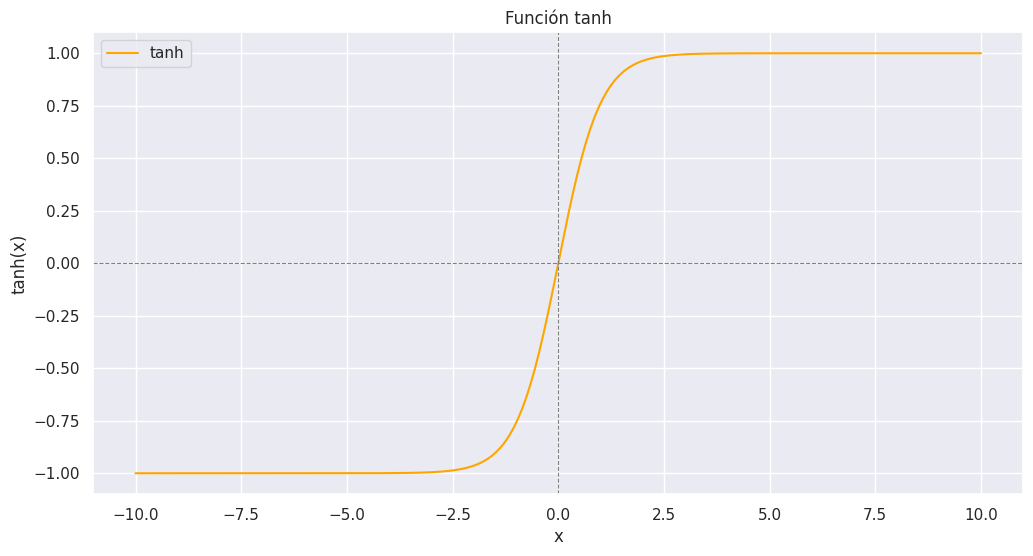

In [6]:
y_tanh = np.tanh(x)

plt.figure()
sns.lineplot(x=x, y=y_tanh, label='tanh', color='orange')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Función tanh')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.legend()
plt.show()

#### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$
Es la activación más usada en redes profundas porque evita el desvanecimiento del gradiente.

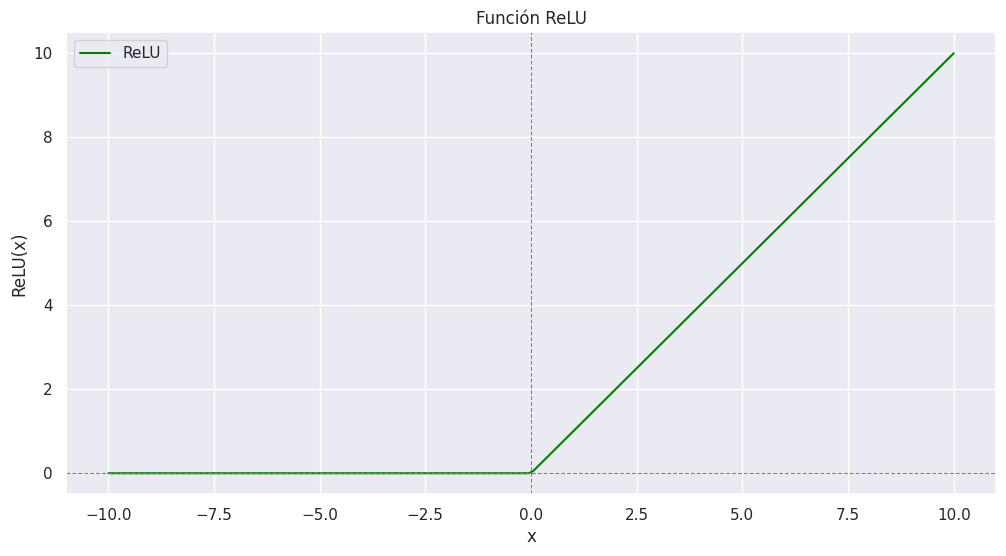

In [7]:
def relu(x):
    return np.maximum(0, x)

y_relu = relu(x)

plt.figure()
sns.lineplot(x=x, y=y_relu, label='ReLU', color='green')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Función ReLU')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.legend()
plt.show()

#### Leaky ReLU
$$\text{LeakyReLU}(x) = \max(\alpha x, x)$$ con $\alpha$ pequeño (ej. 0.01).
Permite un pequeño gradiente cuando $x<0$, evitando neuronas muertas.

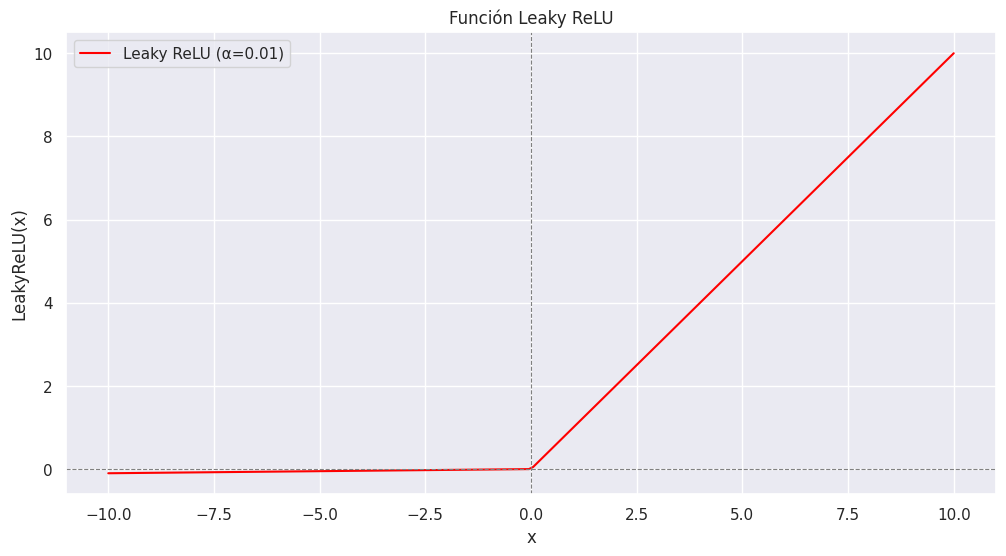

In [8]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

y_leaky = leaky_relu(x)

plt.figure()
sns.lineplot(x=x, y=y_leaky, label='Leaky ReLU (α=0.01)', color='red')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Función Leaky ReLU')
plt.xlabel('x')
plt.ylabel('LeakyReLU(x)')
plt.legend()
plt.show()

#### Swish / SiLU
$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1+e^{-x}}$$
Propuesta por Google, combina características de ReLU y sigmoide. Se usa en modelos avanzados.

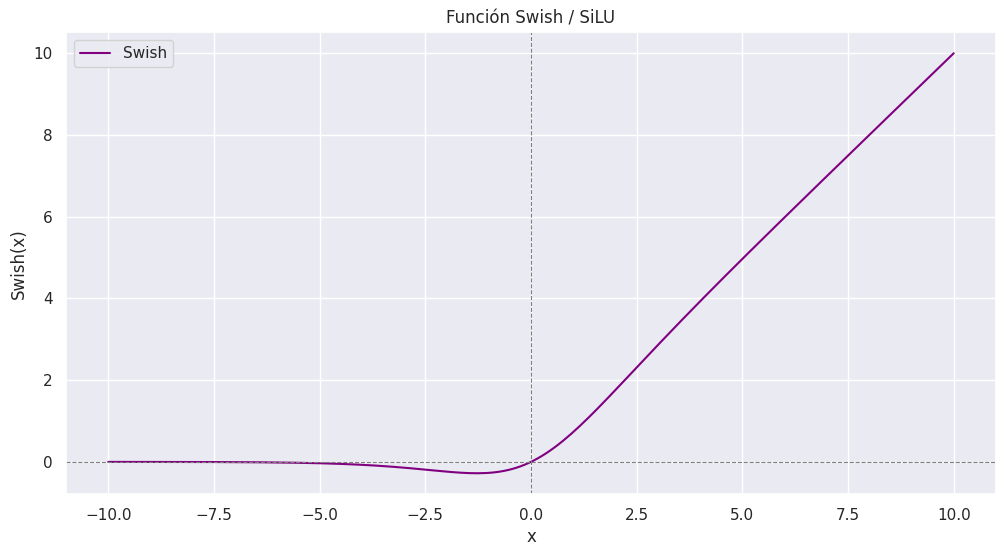

In [9]:
def swish(x):
    return x * sigmoide(x)

y_swish = swish(x)

plt.figure()
sns.lineplot(x=x, y=y_swish, label='Swish', color='purple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Función Swish / SiLU')
plt.xlabel('x')
plt.ylabel('Swish(x)')
plt.legend()
plt.show()

#### Softmax
$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}$$Convierte un vector de valores reales en una distribución de probabilidad. La suma de todas las salidas es exactamente 1, lo que permite interpretar cada valor como la confianza del modelo en una clase específica.

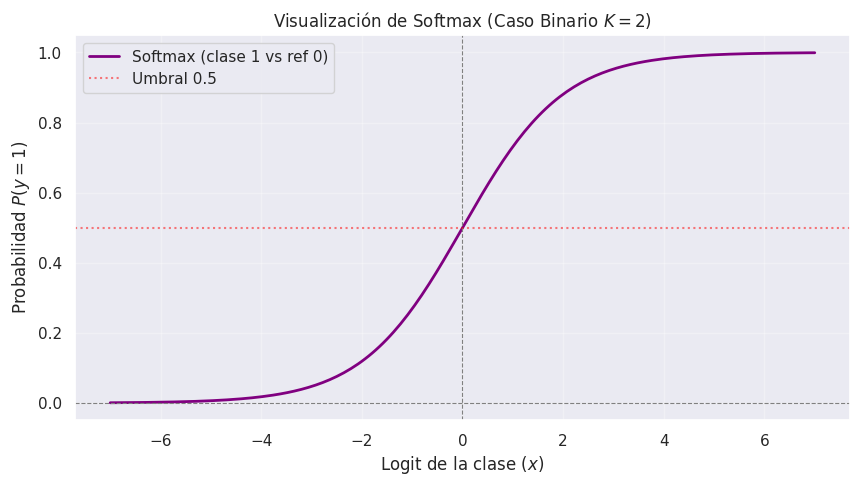

In [39]:
# Definición de Softmax para 2 clases (x y una referencia fija en 0)
def softmax_binary(x):
    # z = [x, 0]
    e_x = np.exp(x)
    e_0 = np.exp(0)
    return e_x / (e_x + e_0)

x = np.linspace(-7, 7, 200)
y = softmax_binary(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='purple', label='Softmax (clase 1 vs ref 0)', linewidth=2)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Umbral 0.5')

plt.title('Visualización de Softmax (Caso Binario $K=2$)')
plt.xlabel('Logit de la clase ($x$)')
plt.ylabel('Probabilidad $P(y=1)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Funciones de Pérdida (Loss Functions)

Miden el error entre la predicción del modelo y el valor real. Son clave para el entrenamiento.

#### Error Cuadrático Medio (MSE)
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Se usa en regresión. Observa la sumatoria.

In [10]:
# Ejemplo de cálculo de MSE con sumatoria
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

mse = np.mean((y_true - y_pred)**2)
print(f"MSE: {mse:.4f}")

# También podemos calcularlo manualmente con un bucle (sumatoria)
suma = 0
n = len(y_true)
for i in range(n):
    suma += (y_true[i] - y_pred[i])**2
mse_manual = suma / n
print(f"MSE con bucle: {mse_manual:.4f}")

MSE: 0.3750
MSE con bucle: 0.3750


#### Error Absoluto Medio (MAE)
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Menos sensible a outliers que el MSE.

In [11]:
mae = np.mean(np.abs(y_true - y_pred))
print(f"MAE: {mae:.4f}")

MAE: 0.5000


#### Entropía Cruzada Binaria (Binary Cross-Entropy)
Para clasificación binaria (dos clases).
$$\text{BCE} = -\frac{1}{n}\sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$
donde $\hat{y}_i$ es la probabilidad predicha (después de sigmoide).

In [12]:
# Ejemplo con dos muestras
y_true_bin = np.array([1, 0, 1, 0])
y_pred_bin = np.array([0.9, 0.2, 0.8, 0.1])  # probabilidades

# Evitamos log(0) añadiendo una pequeña constante
eps = 1e-15
y_pred_bin = np.clip(y_pred_bin, eps, 1 - eps)
bce = -np.mean(y_true_bin * np.log(y_pred_bin) + (1 - y_true_bin) * np.log(1 - y_pred_bin))
print(f"BCE: {bce:.4f}")

BCE: 0.1643


#### Entropía Cruzada Categórica (Categorical Cross-Entropy)
Para clasificación multiclase (más de dos clases).
$$\text{CCE} = -\sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$
suele promediarse sobre las muestras.

In [13]:
# Ejemplo: 3 muestras, 4 clases
y_true_mult = np.array([[1,0,0,0], [0,1,0,0], [0,0,0,1]])  # one-hot
y_pred_mult = np.array([[0.7,0.2,0.05,0.05], [0.1,0.8,0.05,0.05], [0.1,0.1,0.1,0.7]])

# Aseguramos estabilidad numérica
y_pred_mult = np.clip(y_pred_mult, eps, 1 - eps)
cce = -np.mean(np.sum(y_true_mult * np.log(y_pred_mult), axis=1))
print(f"CCE: {cce:.4f}")

CCE: 0.3122


#### Hinge Loss (para SVM)
$$\text{Hinge}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$
donde $y \in \{-1, 1\}$ y $\hat{y}$ es la salida del clasificador (no probabilidad).

In [14]:
def hinge_loss(y_true, y_pred):
    # y_true debe ser -1 o 1
    return np.maximum(0, 1 - y_true * y_pred)

y_true_svm = np.array([1, -1, 1, -1])
y_pred_svm = np.array([0.8, -0.5, 1.2, -0.3])  # scores

hinge = hinge_loss(y_true_svm, y_pred_svm)
print(f"Hinge loss por muestra: {hinge}")
print(f"Hinge loss promedio: {np.mean(hinge):.4f}")

Hinge loss por muestra: [0.2 0.5 0.  0.7]
Hinge loss promedio: 0.3500


#### Focal Loss
Propuesta para detectar objetos, enfocada en ejemplos difíciles.
$$\text{FL}(p_t) = -\alpha_t (1-p_t)^\gamma \log(p_t)$$
donde $p_t$ es la probabilidad para la clase correcta.
Es una generalización de la entropía cruzada binaria.

In [15]:
def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    # y_true: 0 o 1, y_pred: probabilidad
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
    return -alpha_t * (1 - p_t)**gamma * np.log(p_t)

y_true_focal = np.array([1, 0, 1, 0])
y_pred_focal = np.array([0.9, 0.2, 0.3, 0.8])

focal = focal_loss(y_true_focal, y_pred_focal)
print(f"Focal loss por muestra: {focal}")
print(f"Focal loss promedio: {np.mean(focal):.4f}")

Focal loss por muestra: [2.63401289e-04 6.69430654e-03 1.47486669e-01 7.72530198e-01]
Focal loss promedio: 0.2317


#### Contrastive Loss
Usada en siamese networks para aprender embeddings, busca que pares similares estén cerca y pares distintos lejos.
$$\text{Contrastive}(y, D) = y \cdot D^2 + (1-y) \cdot \max(0, m - D)^2$$
donde $y=1$ si son similares, $y=0$ si son distintos, $D$ es la distancia euclidiana entre embeddings, $m$ es un margen.

In [16]:
def contrastive_loss(y, D, margin=1.0):
    return y * D**2 + (1 - y) * np.maximum(0, margin - D)**2

# Ejemplo: dos pares
y_contr = np.array([1, 0])  # primer par similar, segundo distinto
D_contr = np.array([0.5, 1.2])

loss_contr = contrastive_loss(y_contr, D_contr)
print(f"Contrastive loss por par: {loss_contr}")
print(f"Contrastive loss promedio: {np.mean(loss_contr):.4f}")

Contrastive loss por par: [0.25 0.  ]
Contrastive loss promedio: 0.1250


---
## Objetos Matemáticos


### Escalares
Un escalar es un número real (o complejo) simple. En Python puede ser un `int` o `float`.

In [22]:
# Escalar
escalar = 5.2
print(f"Escalar: {escalar}, tipo: {type(escalar)}")

Escalar: 5.2, tipo: <class 'float'>


### Vectores
Un vector es una lista ordenada de números. En IA representa un punto en el espacio de características. Se puede representar con un array de NumPy de una dimensión.

In [23]:
# Vector
vector = np.array([2.5, 1.8, 3.0, 4.2])
print(f"Vector: {vector}, dimensiones: {vector.shape}")

Vector: [2.5 1.8 3.  4.2], dimensiones: (4,)


In [28]:
# Operaciones básicas con vectores
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
print(f"\nSuma de vectores: {v1 + v2}")
print(f"Producto punto: {np.dot(v1, v2)}")


Suma de vectores: [5 7 9]
Producto punto: 32


### Matrices
Una matriz es una tabla bidimensional de números. Por ejemplo, una imagen en escala de grises.

In [29]:
# Matriz
matriz = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"Matriz:\n{matriz}\ndimensiones: {matriz.shape}")


Matriz:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
dimensiones: (3, 3)


In [30]:
m1 = np.array([[1,2],[3,4]])
m2 = np.array([[5,6],[7,8]])
print(f"\nMultiplicación de matrices:\n{m1 @ m2}")


Multiplicación de matrices:
[[19 22]
 [43 50]]


### Tensores
Un tensor es una generalización a más dimensiones. Un lote de imágenes a color es un tensor 4D (batch_size, alto, ancho, canales).

In [31]:
# Tensor 3D
tensor_3d = np.array([
    [[1, 2, 3], [4, 5, 6], [7, 8, 9]],
    [[10,11,12], [13,14,15], [16,17,18]]
])
print(f"Tensor 3D, dimensiones: {tensor_3d.shape}")



Tensor 3D, dimensiones: (2, 3, 3)


In [35]:
# Un lote de imágenes a color es un tensor 4D.
# Creamos un tensor 3D de dimensiones 2 (lote) x 3 (alto) x 3 (ancho) (como dos matrices de 3x3).
tensor_3d = np.array([
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]],

    [[10, 11, 12],
     [13, 14, 15],
     [16, 17, 18]]
])
print("Tensor 3D")
print("Dimensiones:", tensor_3d.shape)
print("\nInterpretación: (capas, filas, columnas)")

# Mostrar cada capa como matriz
for i in range(tensor_3d.shape[0]):
    print(f"\nCapa {i}:")
    print(tensor_3d[i])

# tensor[capa, fila, columna]
print(f"Elemento en capa 0, fila 1, columna 2 del tensor: {tensor_3d[0, 1, 2]}")

Tensor 3D
Dimensiones: (2, 3, 3)

Interpretación: (capas, filas, columnas)

Capa 0:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Capa 1:
[[10 11 12]
 [13 14 15]
 [16 17 18]]
Elemento en capa 0, fila 1, columna 2 del tensor: 6


---
### Aplicaciones de Objetos Matemáticos

### Producto Punto y Similitud de Coseno
El producto punto (dot product) mide la proyección de un vector sobre otro. La similitud de coseno normaliza por las magnitudes:
$$\text{similitud}(A,B) = \frac{A \cdot B}{\|A\| \|B\|}$$
Se usa en sistemas de recomendación, búsqueda de documentos, etc.

In [18]:
A = np.array([1, 2, 3])
B = np.array([2, 4, 6])

producto_punto = np.dot(A, B)
norma_A = np.linalg.norm(A)
norma_B = np.linalg.norm(B)
sim_cos = producto_punto / (norma_A * norma_B)

print(f"Producto punto: {producto_punto}")
print(f"Similitud de coseno: {sim_cos:.4f}")

# Con vectores ortogonales
C = np.array([1, 0, 0])
D = np.array([0, 1, 0])
print(f"Similitud de coseno entre ortogonales: {np.dot(C,D)/(np.linalg.norm(C)*np.linalg.norm(D)):.4f}")

Producto punto: 28
Similitud de coseno: 1.0000
Similitud de coseno entre ortogonales: 0.0000


#### Comparacion de distancias

Espacios Métricos y la Familia de Distancias $L_p$En matemáticas y IA, la distancia no es una medida única, sino una función que debe cumplir tres condiciones: ser positiva, ser cero solo si los puntos son idénticos y cumplir la desigualdad triangular.

La Intuición: Rutas en el Mundo Real
Antes de la fórmula, debemos entender que la "distancia" depende del contexto del movimiento:
* Euclidiana ($L_2$): Es la línea recta "como vuela un pájaro".
* Manhattan ($L_1$): Es la ruta de un taxi entre edificios; no puedes atravesar paredes, debes seguir la cuadrícula. Es el maximo de los valores absolutos de las diferencias de coordenadas
* Chebyshev ($L_\infty$): Es el movimiento del Rey en ajedrez; la distancia es el máximo de pasos en cualquier eje.

 Definición General:
 * Distancia $L_p$ (Norma de Minkowski)
 Podemos generalizar todas estas medidas mediante una sola expresión matemática:

 $$d_p(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}$$
 Para simplificar, si medimos desde el origen ($y=0$), la fórmula se convierte en:
 $$\|x\|_p = (|x_1|^p + |x_2|^p)^{1/p}$$

### Tipos de Distancia

#### Distancia Euclidiana (L2)
$$d_2(A,B) = \sqrt{\sum_{i=1}^n (A_i - B_i)^2}$$

#### Distancia Manhattan (L1)
$$d_1(A,B) = \sum_{i=1}^n |A_i - B_i|$$

#### Distancia de Chebyshev (L∞)
$$d_\infty(A,B) = \max_i |A_i - B_i|$$

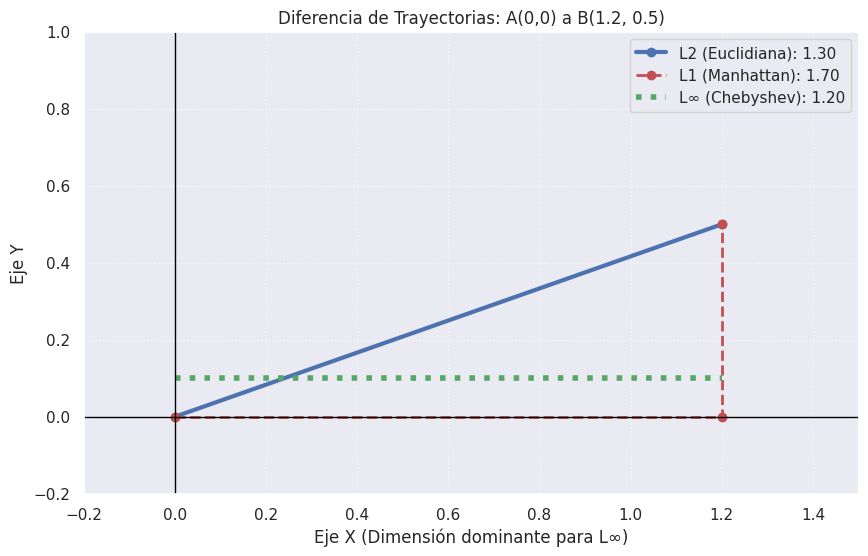

In [43]:
def comparar_metricas_visual():
    A = np.array([0, 0])
    B = np.array([1.2, 0.5])

    plt.figure(figsize=(10, 6))

    # 1. Ruta L2 (Línea Recta)
    plt.plot([A[0], B[0]], [A[1], B[1]], 'b-o', linewidth=3, label=f'L2 (Euclidiana): {np.linalg.norm(B-A):.2f}')

    # 2. Ruta L1 (Manhattan - Escalón)
    plt.plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], 'r--o', linewidth=2, label=f'L1 (Manhattan): {np.abs(B-A).sum():.2f}')

    # 3. Ruta L∞ (Chebyshev - Proyección máxima)
    # Se visualiza mostrando que el camino está dominado por el eje X
    plt.plot([A[0], B[0]], [0.1, 0.1], 'g:', linewidth=4, label=f'L∞ (Chebyshev): {np.abs(B-A).max():.2f}')

    # Estética de la gráfica
    plt.title('Diferencia de Trayectorias: A(0,0) a B(1.2, 0.5)')
    plt.xlabel('Eje X (Dimensión dominante para L∞)')
    plt.ylabel('Eje Y')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.legend()
    plt.xlim(-0.2, 1.5)
    plt.ylim(-0.2, 1.0)
    plt.show()

comparar_metricas_visual()

Concepto de bola:
Se representa el lugar geométrico de todos los puntos $(x, y)$ cuya distancia al origen es exactamente 1.

Una bola en matemáticas se define como el conjunto de todos los puntos que están a una distancia menor o igual a $R$ de un centro. Al cambiar $p$, la forma de la "bola" cambia drásticamente, demostrando que no todas las bolas son redondas.

La gráfica de las **"Bolas de Unidad"** ($Unit\ Balls$) representa todos los puntos $(x, y)$ que se encuentran a una distancia exacta de **1** respecto al origen $(0,0)$. La forma geométrica resultante define el comportamiento de cada métrica:



#### **Resumen de Métricas**

| Métrica | Forma | Interpretación | Uso en IA / NLP |
| :--- | :--- | :--- | :--- |
| **L1 (Manhattan)** | **Rombo** | Suma de diferencias absolutas. | **Sparsity:** Selección de variables y modelos robustos a ruido. |
| **L2 (Euclidiana)** | **Círculo** | Distancia física en línea recta. | **Clustering:** Estándar en K-Means y optimización de errores (MSE). |
| **L∞ (Chebyshev)** | **Cuadrado** | Máxima diferencia entre ejes. | **Logística:** Casos donde solo importa el factor más extremo. |

> **Nota Pedagógica:** > * **Relación de área:** La distancia L1 es la más restrictiva (está contenida en las demás). Para un mismo valor de distancia, el camino en "L1" siempre será igual o más largo que en "L2".
> * **NLP:** En espacios de alta dimensionalidad (como vectores de palabras), la distancia L2 pierde efectividad, prefiriéndose métricas como **L1** o la **Distancia Coseno**.

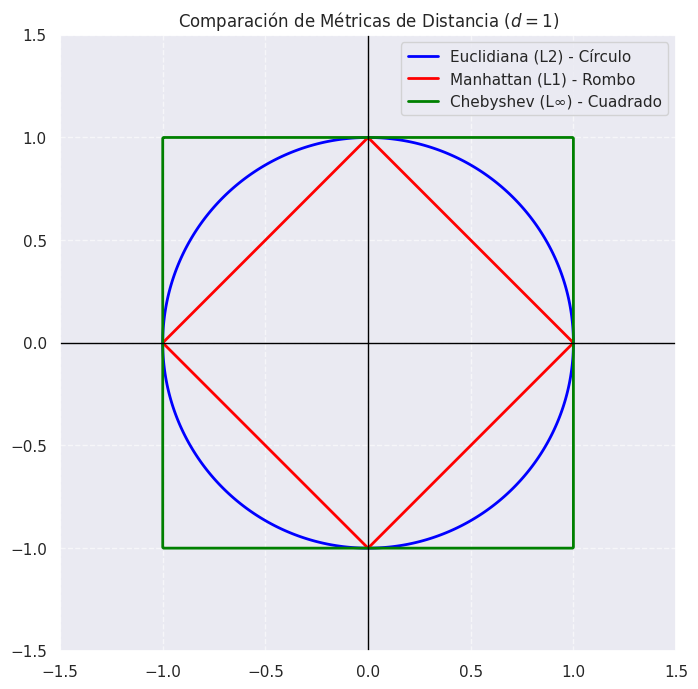

In [45]:
def plot_distance_shapes():
    # Crear una rejilla de puntos
    x = np.linspace(-1.5, 1.5, 400)
    y = np.linspace(-1.5, 1.5, 400)
    X, Y = np.meshgrid(x, y)

    # Definir las distancias desde el origen (0,0)
    l2 = np.sqrt(X**2 + Y**2)          # Euclidiana
    l1 = np.abs(X) + np.abs(Y)         # Manhattan
    linf = np.maximum(np.abs(X), np.abs(Y)) # Chebyshev

    plt.figure(figsize=(8, 8))

    # Graficar los contornos donde la distancia es igual a 1
    plt.contour(X, Y, l2, levels=[1], colors='blue', linewidths=2)
    plt.contour(X, Y, l1, levels=[1], colors='red', linewidths=2)
    plt.contour(X, Y, linf, levels=[1], colors='green', linewidths=2)

    # Estética de la gráfica
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Leyenda personalizada
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='blue', lw=2),
                    Line2D([0], [0], color='red', lw=2),
                    Line2D([0], [0], color='green', lw=2)]
    plt.legend(custom_lines, ['Euclidiana (L2) - Círculo',
                              'Manhattan (L1) - Rombo',
                              'Chebyshev (L∞) - Cuadrado'])

    plt.title('Comparación de Métricas de Distancia ($d=1$)')
    plt.gca().set_aspect('equal')
    plt.show()

plot_distance_shapes()

### Kernel RBF (Radial Basis Function)
El kernel RBF es muy usado en SVM y procesos gaussianos:
$$K(x, y) = \exp\left(-\frac{\|x-y\|^2}{2\sigma^2}\right)$$
Mide la similitud entre dos puntos; decae con la distancia.

In [20]:
def rbf_kernel(x, y, sigma=1.0):
    return np.exp(-np.linalg.norm(x - y)**2 / (2 * sigma**2))

a = np.array([1, 1])
b = np.array([2, 2])
c = np.array([10, 10])

print(f"RBF entre a y b (σ=1): {rbf_kernel(a, b):.4f}")
print(f"RBF entre a y c (σ=1): {rbf_kernel(a, c):.4f}")

# Podemos variar sigma
print(f"RBF entre a y b (σ=2): {rbf_kernel(a, b, sigma=2):.4f}")

RBF entre a y b (σ=1): 0.3679
RBF entre a y c (σ=1): 0.0000
RBF entre a y b (σ=2): 0.7788


### Ejemplo Integrador: Clasificación con SVM y Kernel RBF
Aunque no implementaremos un SVM completo, podemos ver cómo el kernel transforma la similitud.

Generamos dos grupos de puntos y calculamos la matriz de kernel RBF entre ellos.

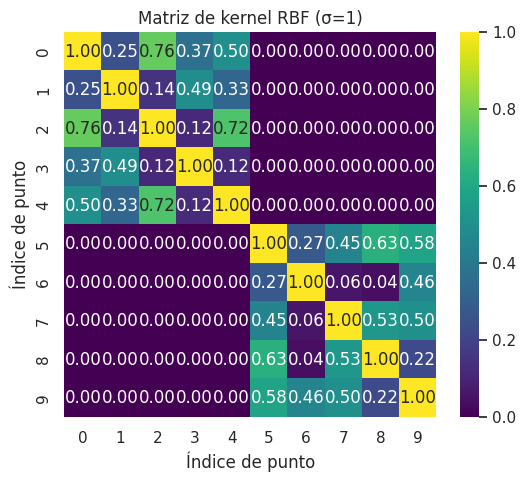

In [21]:
# Generamos datos de ejemplo
np.random.seed(42)
X1 = np.random.randn(5, 2) + np.array([2, 2])  # clase 1
X2 = np.random.randn(5, 2) + np.array([-2, -2]) # clase 2
X = np.vstack([X1, X2])

# Calculamos la matriz de kernel RBF (similitud entre todos los pares)
sigma = 1.0
n = len(X)
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K[i,j] = rbf_kernel(X[i], X[j], sigma)

# Visualizamos la matriz de kernel
plt.figure(figsize=(6,5))
sns.heatmap(K, cmap='viridis', annot=True, fmt='.2f')
plt.title('Matriz de kernel RBF (σ=1)')
plt.xlabel('Índice de punto')
plt.ylabel('Índice de punto')
plt.show()

# Observamos que puntos de la misma clase tienen mayor similitud.

---
## Conclusiones

*   Hemos repasado la **notación de sumatorias y productorias** con ejemplos numéricos, base de muchos cálculos en IA.
*   Visualizamos las principales **funciones de activación** (sigmoide, tanh, ReLU, Leaky ReLU, Swish) y **funciones de pérdida** (MSE, MAE, cross-entropy, hinge, focal, contrastive), comprendiendo su forma y utilidad.
*   Definimos los **objetos matemáticos** (escalares, vectores, matrices, tensores) y realizamos operaciones básicas con NumPy.
*   Exploramos **aplicaciones prácticas** como la similitud de coseno, distancias y el kernel RBF, que son herramientas fundamentales en algoritmos de aprendizaje automático.

Todo esto constituye la base matemática sobre la que se construyen los modelos de inteligencia artificial.